In [5]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [6]:
import sklearn
from sklearn.decomposition import PCA

In [7]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [593]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k/((freq-center)**2 + (k/2)**2)

In [490]:
header = "D:/K_sunada/result/CDY152/"
data10r = "/2023-12-10/2023-12-10T110819_fd34a1e5-cw_attenuation"
data10 = "/2023-12-10/2023-12-10T100849_acfd0d73-cw_attenuation"
data15 = "/2023-12-08/2023-12-08T211039_cd69f97e-cw_attenuation"
data20 = "/2023-12-08/2023-12-08T202129_ef137feb-cw_attenuation"
data30 = "/2023-12-08/2023-12-08T203614_feb6adbf-cw_attenuation"
data100 = "/2023-12-10/2023-12-10T092320_52ba17b3-cw_attenuation"
data200 = "/2023-12-10/2023-12-10T093108_6976ba9d-cw_attenuation"
data500 = "/2023-12-10/2023-12-10T094604_7f6fa440-cw_attenuation"
data800 = "/2023-12-10/2023-12-10T095609_e84089aa-cw_attenuation"
dd10r = datadict_from_hdf5(header + data10r +"/data")
dd10 = datadict_from_hdf5(header + data10 +"/data")
dd15 = datadict_from_hdf5(header + data15 +"/data")
dd20 = datadict_from_hdf5(header + data20 +"/data")
dd30 = datadict_from_hdf5(header + data30 +"/data")
dd100 = datadict_from_hdf5(header + data100 + "/data")
dd200 = datadict_from_hdf5(header + data200 + "/data")
dd500 = datadict_from_hdf5(header + data500 + "/data")
dd800 = datadict_from_hdf5(header + data800 + "/data")

detune' -0.5MHz

In [491]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd10r['frequency']['values'][ini:fin]
    y = dd10r['s11']['values'][ini:fin].real
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]

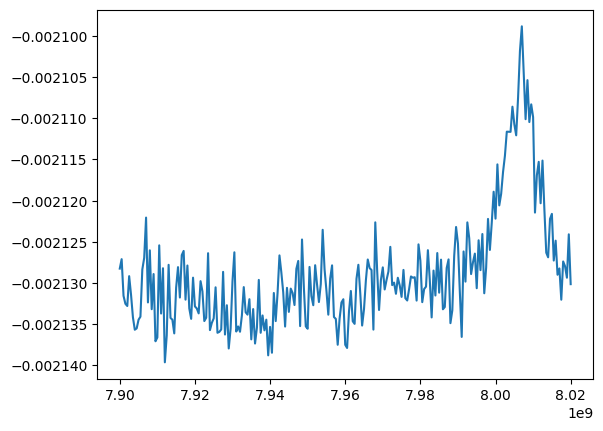

In [20]:
plt.plot(xs[0], ys[0])
plt.show()

In [492]:
par_ini = {'amp': 0.000035,'const':13, 'center':8e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

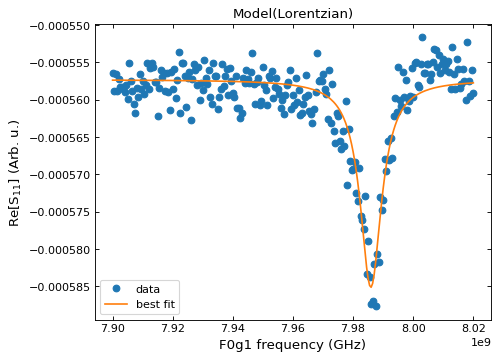

In [502]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [504]:
center10r = [8.0197e+09, 8.0190e+09, 8.0180e+09, 8.0168e+09, 8.0157e+09, 8.0146e+09,
            8.0133e+09, 8.0119e+09, 8.0104e+09, 8.0091e+09, 8.0075e+09, 8.0056e+09,
            8.0041e+09, 8.0021e+09, 7.9999e+09, 7.9979e+09, 7.9959e+09, 7.9938e+09,
            7.9914e+09, 7.9886e+09, 7.9859e+09]

detune -1MHz

In [406]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd10['frequency']['values'][ini:fin]
    y = dd10['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]

In [425]:
par_ini = {'amp': 0.000035,'const':13, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

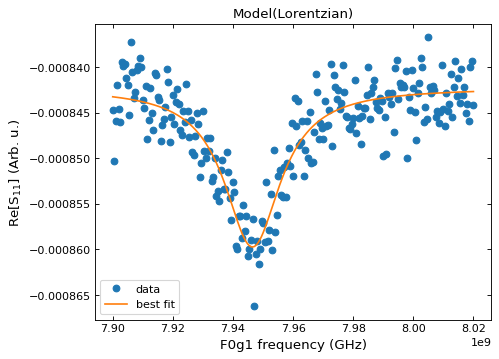

In [430]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [431]:
center10 = [8.0074e+09, 8.0057e+09, 8.0042e+09, 8.0019e+09, 8.0000e+09, 7.9980e+09,
            7.9952e+09, 7.9933e+09, 7.9907e+09, 7.9888e+09, 7.9859e+09, 7.9820e+09,
            7.9799e+09, 7.9745e+09, 7.9728e+09, 7.9688e+09, 7.9641e+09, 7.9610e+09, 
            7.9543e+09, 7.9525e+09, 7.9465e+09]

detune -1.5MHz

In [80]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd15['frequency']['values'][ini:fin]
    y = dd15['s11']['values'][ini:fin].real
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]

In [100]:
par_ini = {'amp': 0.000035,'const':13, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

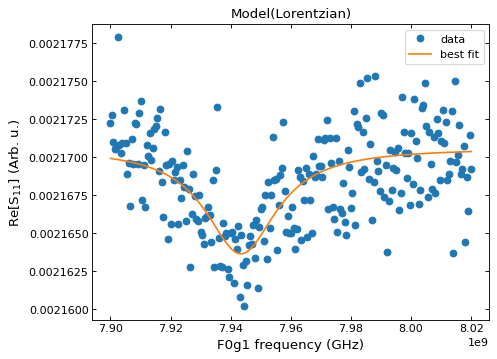

In [106]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [160]:
center15 = [8.0067e+09, 8.0052e+09, 8.0040e+09, 8.0004e+09, 7.9989e+09, 7.9957e+09,
          7.9949e+09, 7.9929e+09, 7.9898e+09, 7.9864e+09, 7.9852e+09, 7.9817e+09,
          7.9773e+09, 7.9746e+09, 7.9709e+09, 7.9674e+09, 7.9612e+09, 7.9604e+09,
          7.9564e+09, 7.9510e+09, 7.9434e+09]

detune -2MHz

In [128]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd20['frequency']['values'][ini:fin]
    y = dd20['s11']['values'][ini:fin].real
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

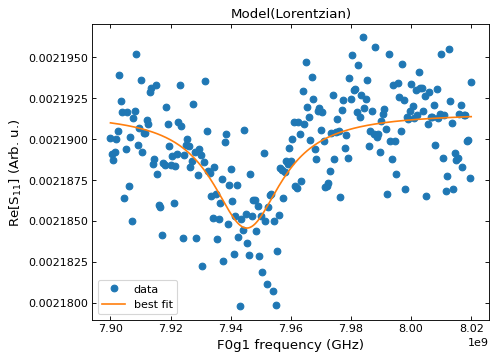

In [133]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [161]:
center20 = [8.0049e+09, 8.0042e+09, 8.0028e+09, 8.0000e+09, 7.9987e+09, 7.9969e+09,
          7.9941e+09, 7.9907e+09, 7.9891e+09, 7.9860e+09, 7.9827e+09, 7.9816e+09,
          7.9782e+09, 7.9745e+09, 7.9688e+09, 7.9644e+09, 7.9631e+09, 7.9592e+09,
          7.9528e+09, 7.9451e+09, 7.9453e+09]

detune -3MHz

In [151]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd30['frequency']['values'][ini:fin]
    y = dd30['s11']['values'][ini:fin].real
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

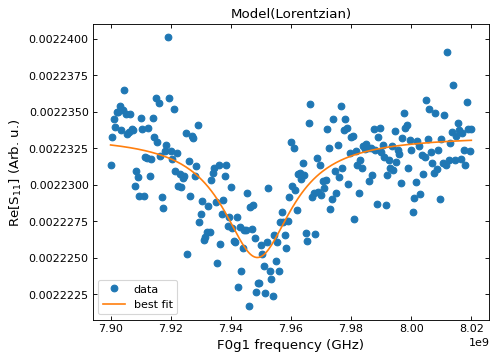

In [157]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [162]:
center30 = [8.0064e+09, 8.0047e+09, 8.0039e+09, 8.0008e+09, 7.9993e+09, 7.9966e+09,
          7.9935e+09, 7.9929e+09, 7.9897e+09, 7.9872e+09, 7.9832e+09, 7.9800e+09,
          7.9779e+09, 7.9717e+09, 7.9738e+09, 7.9637e+09, 7.9622e+09, 7.9599e+09,
          7.9544e+09, 7.9473e+09, 7.9488e+09]

detune -10MHz

In [266]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd100['frequency']['values'][ini:fin]
    y = dd100['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

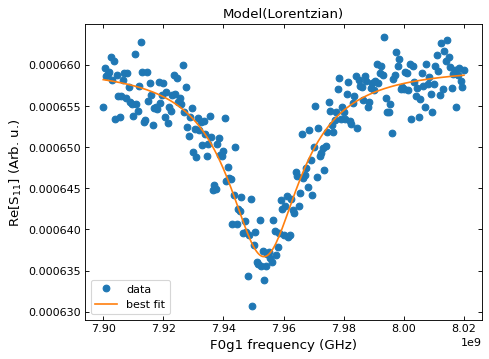

In [268]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [300]:
center100 = [8.0096e+09, 8.0075e+09, 8.0079e+09, 8.0013e+09, 8.0028e+09, 8.0007e+09,
             7.9990e+09, 7.9965e+09, 7.9939e+09, 7.9926e+09, 7.9890e+09, 7.9862e+09,
             7.9837e+09, 7.9804e+09, 7.9777e+09, 7.9751e+09, 7.9703e+09, 7.9668e+09,
             7.9632e+09, 7.9588e+09, 7.9535e+09]

detune -20MHz

In [308]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd200['frequency']['values'][ini:fin]
    y = dd200['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

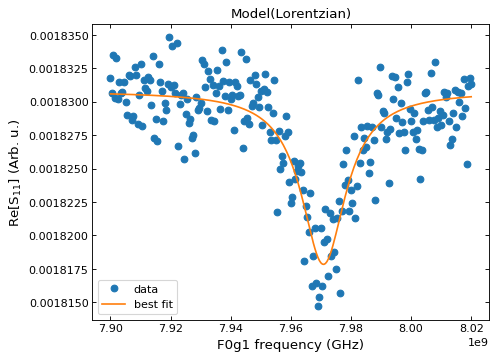

In [329]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [330]:
center200 = [8.0135e+09, 8.0135e+09, 8.0121e+09, 8.0089e+09, 8.0081e+09, 8.0073e+09, 
             8.0057e+09, 8.0033e+09, 8.0015e+09, 8.0019e+09, 7.9992e+09, 7.9950e+09,
             7.9943e+09, 7.9918e+09, 7.9884e+09, 7.9864e+09, 7.9836e+09, 7.9801e+09,
             7.9771e+09, 7.9746e+09, 7.9709e+09] 

detune -50MHz

In [354]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd500['frequency']['values'][ini:fin]
    y = dd500['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':8.02e9,'k':0.001e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

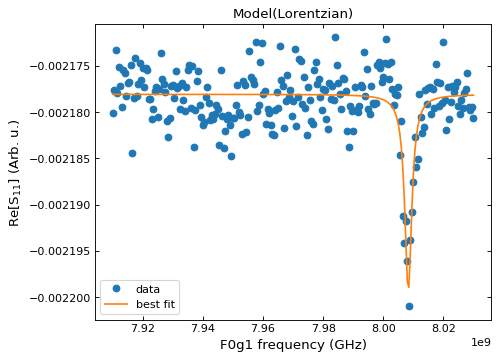

In [371]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [372]:
center500 = [8.0264e+09, 8.0261e+09, 8.0253e+09, 8.0249e+09, 8.0242e+09, 8.0237e+09, 
             8.0229e+09, 8.0223e+09, 8.0213e+09, 8.0207e+09, 8.0196e+09, 8.0185e+09,
             8.0179e+09, 8.0170e+09, 8.0157e+09, 8.0147e+09, 8.0135e+09, 8.0124e+09,
             8.0109e+09, 8.0093e+09, 8.0083e+09] 

detune -80MHz

In [397]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd800['frequency']['values'][ini:fin]
    y = dd800['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)
xs = xs[0]
ys = ys[0]
par_ini = {'amp': 0.000035,'const':13, 'center':8.02e9,'k':0.001e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

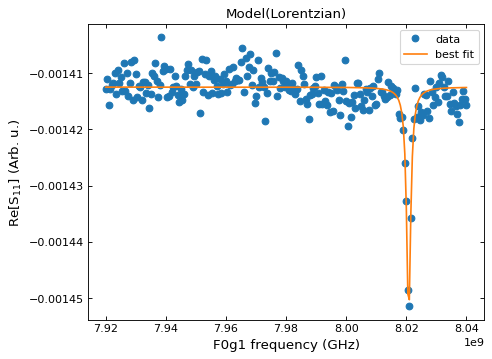

In [402]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [403]:
center800 = [8.0305e+09, 8.0303e+09, 8.0300e+09, 8.0296e+09, 8.0293e+09, 8.0290e+09,
             8.0287e+09, 8.0282e+09, 8.0278e+09, 8.0275e+09, 8.0270e+09, 8.0266e+09,
             8.0260e+09, 8.0255e+09, 8.0249e+09, 8.0244e+09, 8.0237e+09, 8.0230e+09,
             8.0222e+09, 8.0216e+09, 8.0208e+09] 

In [664]:
power_dBm = np.linspace(-10, -5, 21)
power_W = 10**((power_dBm)/10) *1e-3

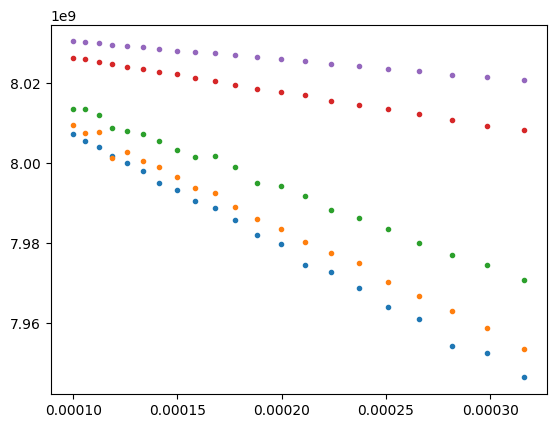

In [665]:
plt.plot(power_W, center10, '.')
plt.plot(power_W, center100, '.')
plt.plot(power_W, center200, '.')
plt.plot(power_W, center500, '.')
plt.plot(power_W, center800, '.')
plt.show()

In [666]:
def liner_func(power, alpha, const):
    return const - alpha*power

In [667]:
par_ini = {'alpha': 0.015e9/0.00005,'const':8.005e9}
par_min = {'alpha': -np.inf,'const':-np.inf}
par_max = {'alpha': np.inf,'const':np.inf}
par_vary = {'alpha': True,'const':True}
model = lmfit.Model(liner_func)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result10r = model.fit(data = center10r, params=params, power = power_W)
result1 = model.fit(data = center10, params=params, power = power_W)
result10 = model.fit(data = center100, params=params, power = power_W)
result20 = model.fit(data = center200, params=params, power = power_W)
result50 = model.fit(data = center500, params=params, power = power_W)
result80 = model.fit(data = center800, params=params, power = power_W)

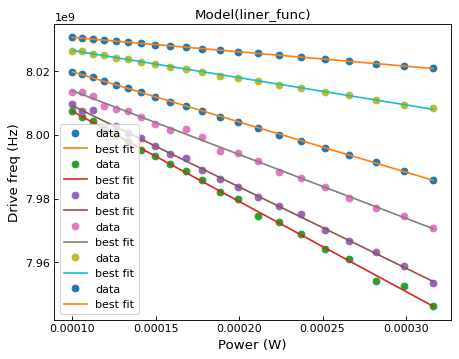

In [668]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")

result10r.plot_fit(ax = ax)
result1.plot_fit(ax = ax)
result10.plot_fit(ax = ax)
result20.plot_fit(ax = ax)
result50.plot_fit(ax = ax)
result80.plot_fit(ax = ax)
ax.set_xlabel('Power (W)', size='large')
ax.set_ylabel('Drive freq (Hz)', size='large')
plt.show()
result10r

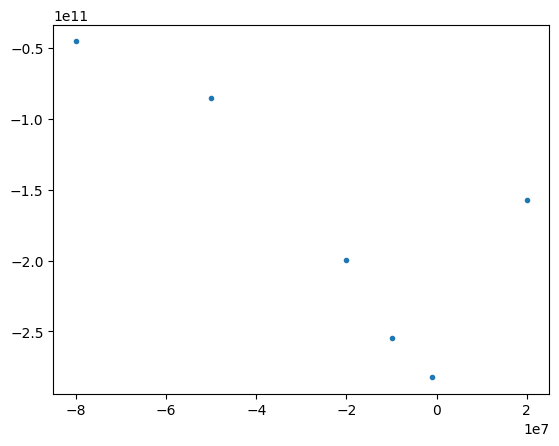

In [669]:
x = np.array([20, -1, -10, -20, -50, -80])*1e6
alpha = np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])
plt.plot(x, alpha, '.')
plt.show()

In [932]:
from scipy.constants import *

In [1105]:
# k_sunada - dpr model
# k_f =0.21238950e9
chi_Hz = -1250000.0
chi = chi_Hz*2*np.pi

omega_p = (10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
# omega_f = 10.1676834e9 *2*np.pi
# omega_r =10.2557302e9*2*np.pi

# g = 0.1011e9
slope= np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])*2*np.pi
P = 0.0002
# P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5
Delta_q = np.array(slope*P * 2*np.pi)
# delta_f = omega_p-omega_f
# delta_r = omega_p-omega_r

def coeff1(k_f, delta_r, delta_f, g):
    numer = k_f *g**2/(delta_f**2 + (k_f/2)**2)
    denom = (delta_r + delta_f *g**2/(delta_f**2 + (k_f/2)**2))**2 +(k_f/2 *g**2/(delta_f**2 + (k_f/2)**2))**2
    return numer/denom

def ac_stark_shift(omega,  omega_r, omega_f, k_f, g, alpha):
    return 2*chi*alpha/(hbar*omega)*coeff1(k_f=k_f, delta_r=omega-omega_r, delta_f=omega-omega_f, g=g)

In [1112]:
x=(10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
par_ini = {'omega_r':10.255e9*2*np.pi, 'omega_f':10.168e9*2*np.pi,
           'k_f':0.21e9*2*np.pi,'g':0.100e9*2*np.pi, 'alpha':18e-11}
par_min = {'omega_r':0, 'omega_f':0,'k_f':0,'g':0, 'alpha':0}
par_max = {'omega_r':np.inf,'omega_f':np.inf, 'k_f':np.inf,'g':np.inf, 'alpha':np.inf}
par_vary = { 'omega_r':True,'omega_f':True, 'k_f':True,'g':True, 'alpha':True}
model = lmfit.Model(ac_stark_shift)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = slope, params=params, omega =x )

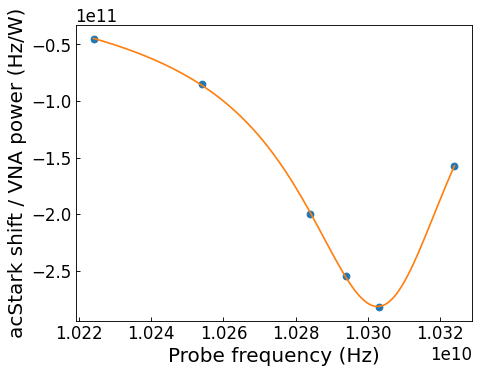

In [1115]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 15
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")

# result.plot_fit(ax = ax)# result = model.fit(y, params, x=x)

x_interp = np.linspace(10.304e9-80e6, 10.304e9+20e6, 100*alpha.size)*2*np.pi
y_interp = result.model.func(x_interp, **result.best_values)

plt.plot(x/(2*np.pi), slope/(2*np.pi),'o', label='original')
plt.plot(x_interp/(2*np.pi), y_interp/(2*np.pi), label='interpolated')
# ax.plot(x/(2*np.pi),result.init_fit)
ax.set_xlabel('Probe frequency (Hz)', size='large')
ax.set_ylabel('acStark shift / VNA power (Hz/W)', size='large')
plt.show()
result

In [1098]:
6.4944e+10/(2*np.pi),6.3991e+10/(2*np.pi),9.8689e+08/(2*np.pi), 5.0225e+08/(2*np.pi)


(10336158624.160051, 10184483963.393475, 157068421.7879606, 79935570.16790444)

In [1100]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

In [1114]:
watt_dbm(6.1707e-11	*1e-3) + 50


-52.09665567102326

In [808]:
par_ini = {'amp': 3e17,'const':0, 'center':0,'k':30e6}
par_min = {'amp': 0, 'const':-np.inf,'center':-np.inf,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = alpha, params=params, freq =x )

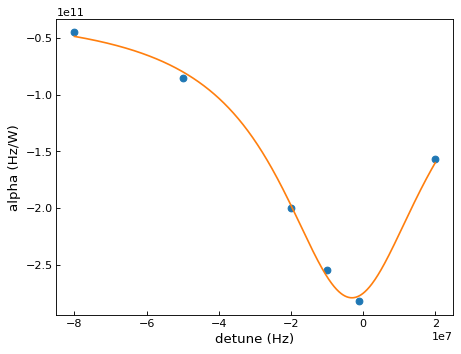

In [809]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")

# result.plot_fit(ax = ax)
# ax.plot(x,result.init_fit)
# result = model.fit(y, params, x=x)

x_interp = np.linspace(-80e6, 20e6, 100*alpha.size)
# The model is attached to the result, which makes it easier if you're sending it somewhere.
y_interp = result.model.func(x_interp, **result.best_values)

plt.plot(x, alpha,'o', label='original')
plt.plot(x_interp, y_interp, label='interpolated')

ax.set_xlabel('detune (Hz)', size='large')
ax.set_ylabel('alpha (Hz/W)', size='large')
plt.show()
result

In [458]:
from scipy.constants import *

In [655]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

In [786]:
# kono-san
alpha= 2e18
k_e = 1.8e6 *2*np.pi
omega_p = 10.36995e9 *2*np.pi
omega_rg = 10.36895e9*2*np.pi
kai = 0.815e6*2*np.pi
delta_q = 40e6 * 2*np.pi
P = 25e-9

def coeff1(k_e=k_e, omega_rg=omega_rg, omega_p= omega_p):
    return k_e / ((omega_p-omega_rg)**2 + (k_e/2)**2)

def photon_flux(P=P,omega_p=omega_p):
    return P/hbar/omega_p

print(10*np.log10(delta_q/kai/coeff1()/photon_flux()))
print((omega_p-omega_rg)**2 )

-70.69418996137921
39478417604391.69


In [739]:
# k_sunada
alpha= np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])
k_e = 49166881.3 *2*np.pi
omega_p =(10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
omega_rg =(10.304e9-3085983.39)*2*np.pi
kai = 5e6/2*2*np.pi
P = 0.0002
delta_q = np.array(alpha*P * 2*np.pi)


def coeff1(k_e=k_e, omega_rg=omega_rg, omega_p= omega_p):
    return k_e / ((omega_p-omega_rg)**2 + (k_e/2)**2)

def photon_flux(P=P,omega_p=omega_p):
    return P/hbar/omega_p

atten_dBm = 10*np.log10(-delta_q/kai/coeff1()/photon_flux())
print(atten_dBm)

[-102.03887577 -102.21916548 -102.37267868 -102.07645818 -100.80665272
  -99.92509721]


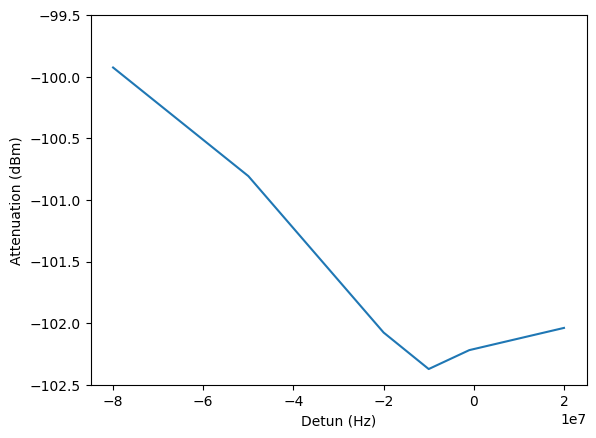

In [743]:
plt.xlabel('Detun (Hz)')
plt.ylabel('Attenuation (dBm)')
plt.ylim(-102.5, -99.5)
plt.plot(x, atten_dBm)

In [744]:
# k_sunada - dpr model
k_eff = 49166881.3 *2*np.pi
k_f = 212e6*2*np.pi
omega_p = (10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
omega_f = 10.168e9 *2*np.pi
omega_rg =(10.304e9-3085983.39)*2*np.pi

g = 0.1011e9*2*np.pi
chi = 5e6/2*2*np.pi
alpha= np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])
P = 0.0002
P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5

delta_q = np.array(alpha*P * 2*np.pi)

def coeff1(k_e=k_eff, omega_rg=omega_rg, omega_p= omega_p):
    return k_e / ((omega_p-omega_rg)**2 + (k_e/2)**2)

def photon_flux(P=P_eff,omega_p=omega_p):
    return P/hbar/omega_p

atten_dBm = 10*np.log10(delta_q/chi/coeff1()/photon_flux())

[1.82896884e+19+2.69169000e+19j 2.21284708e+19+2.81824864e+19j
 2.40667179e+19+2.86076080e+19j 2.64511313e+19+2.89465210e+19j
 3.51568372e+19+2.85234717e+19j 4.57114016e+19+2.41494197e+19j]


d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


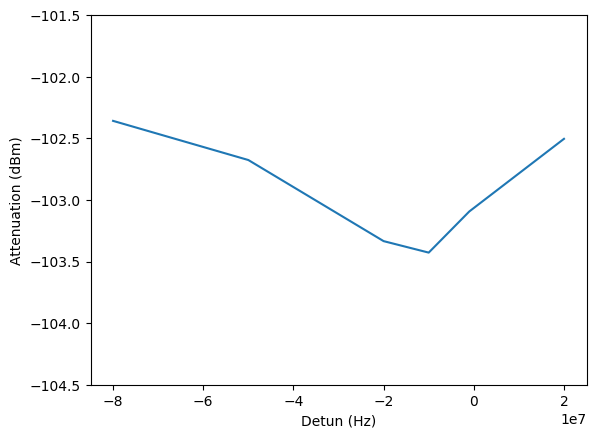

In [745]:
plt.xlabel('Detun (Hz)')
plt.ylabel('Attenuation (dBm)')
plt.ylim(-104.5, -101.5)
plt.plot(x, atten_dBm)

In [888]:
f_hg = 10.268e9
f_lg = 10.147e9
f_he = 10.263e9
f_le = 10.147e9

chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2
chi = (chi_h+chi_l)/2
chi

-1250000.0

In [ ]:
omega_r	1.0428e+10	1217.91850	(0.00%)	10304000000.0	0.00000000	inf	True
omega_f	1.0060e+10	708.100817	(0.00%)	10190000000.0	0.00000000	inf	True
k_f	67142252.7	785.754767	(0.00%)	212000000.0	0.00000000	inf	True
g	1.7736e+08	1

In [861]:
6.5531e+10/(2*np.pi), 6.3206e+10/(2*np.pi), 4.1493e+08/(2*np.pi), 1.1216e+09/(2*np.pi)

(10429582575.754993, 10059547333.066338, 66038160.53712013, 178508184.1718698)

-55.617920429060234


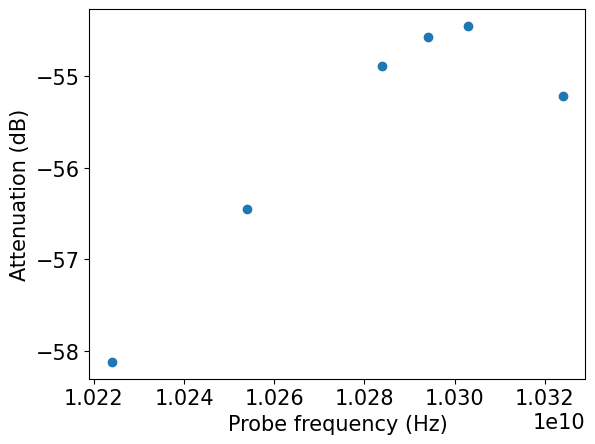

In [924]:
# k_sunada - dpr model
k_f =67142252*2*np.pi#0.21238950e9*2*np.pi
chi_Hz = -1500000.0
chi = chi_Hz*2*np.pi

omega_p = (10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
omega_f = 1.0060e+10*2*np.pi#10.1676834e9 *2*np.pi
omega_r =1.0428e+10*2*np.pi#10.2557302e9*2*np.pi

g = 1.7736e+08*2*np.pi#0.1011e9*2*np.pi
alpha= np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])
P = 0.0002
# P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5
Delta_q = np.array(alpha*P * 2*np.pi)
delta_f = omega_p-omega_f
delta_r = omega_p-omega_r

def coeff1(k_f=k_f, delta_r=delta_r, delta_f=delta_f, g=g):
    numer = k_f *g**2/(delta_f**2 + (k_f/2)**2)
    denom = (delta_r + delta_f *g**2/(delta_f**2 + (k_f/2)**2))**2 +(k_f/2 *g**2/(delta_f**2 + (k_f/2)**2))**2
    return numer/denom

def photon_flux(P=P,omega_p=omega_p):
    return P/hbar/omega_p

atten_dB = 10*np.log10(Delta_q/(2*chi)/coeff1()/photon_flux())
plt.rcParams["font.size"] = 15
plt.xlabel('Probe frequency (Hz)')
plt.ylabel('Attenuation (dB)')
# plt.ylim(-104.5, -101.5)
plt.plot(x, atten_dB+50, 'o')
print(np.mean(atten_dB+50))

[30394058.8380018  36685218.54767594 39857178.27200011 43755562.96402913
 57958445.88930907 75122674.75943229]


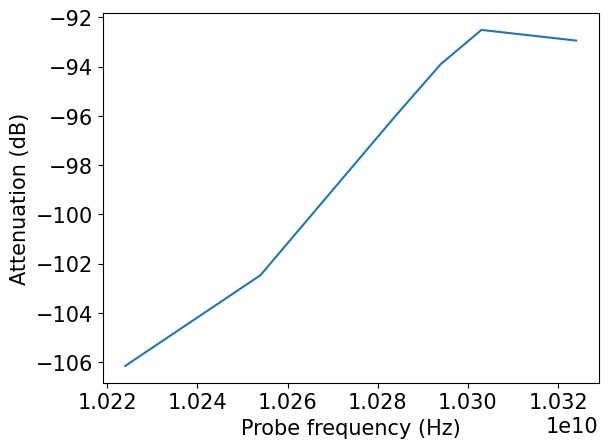

In [920]:
# k_sunada - dpr model
k_f =0.21238950e9*2*np.pi
chi_Hz = -1500000.0
chi = chi_Hz*2*np.pi

omega_p = (10.304e9+ np.array([20, -1, -10, -20, -50, -80])*1e6)*2*np.pi
omega_f = 10.1676834e9 *2*np.pi
omega_r =10.2557302e9*2*np.pi

g = 0.1011e9*2*np.pi
alpha= np.array([-1.5724e+11, -2.8242e+11, -2.5467e+11, -1.9988e+11, -8.5240e+10, -4.5060e+10])
P = 0.0002
# P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5
Delta_q = np.array(alpha*P * 2*np.pi)
delta_f = omega_p-omega_f
delta_r = omega_p-omega_r

def coeff1(k_f=k_f, delta_r=delta_r, delta_f=delta_f, g=g):
    numer = k_f *g**2/(delta_f**2 + (k_f/2)**2)
    denom = (delta_r + delta_f *g**2/(delta_f**2 + (k_f/2)**2))**2 +(k_f/2 *g**2/(delta_f**2 + (k_f/2)**2))**2
    return numer/denom

def photon_flux(P=P,omega_p=omega_p):
    return P/hbar/omega_p

atten_dB = 10*np.log10(Delta_q/(2*chi)/coeff1()/photon_flux())
plt.rcParams["font.size"] = 15
plt.xlabel('Probe frequency (Hz)')
plt.ylabel('Attenuation (dB)')
# plt.ylim(-104.5, -101.5)
plt.plot(x, atten_dB)
print(k_f/2 *g**2/(delta_f**2 + (k_f/2)**2)/(2*np.pi))